# Gasoline: Which variables are the strongest predictors for supply and demand?

This notebook ranks individual predictors for next-month U.S. supply and demand. 

Supply and demand are separate targets.


In [1]:
FUEL = 'gasoline'
from pathlib import Path
import sys, hashlib, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
import sklearn
pd.set_option('display.max_rows', 60)
pd.set_option('display.max_colwidth', 100)
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'oil/us_snd_crude/crude_data.py').exists())
for fuel in ['crude', 'gasoline']:
    sys.path.insert(0, str(ROOT/f'oil/us_snd_{fuel}'))
from crude_data import load_panel as load_crude, FLOWS as CRUDE_FLOWS
from gasoline_data import load_panel as load_gasoline, FLOWS as GAS_FLOWS
panels = {'crude': load_crude(), 'gasoline': load_gasoline()}
national = {}
for fuel, panel in panels.items():
    assert panel.groupby('month').padd.nunique().eq(5).all()
    cols = (CRUDE_FLOWS + ['stock_kb', 'cdu_capacity_kbd']) if fuel == 'crude' else GAS_FLOWS + ['stock_kb']
    z = panel.groupby('month')[cols].sum(min_count=5).asfreq('MS')
    assert z.notna().all().all()
    # Every flow becomes thousand barrels/day; stocks become million barrels.
    if fuel == 'gasoline':
        for c in GAS_FLOWS:
            z[c.replace('_kb', '_kbd')] = z[c] / z.index.days_in_month
    z['stock_mb'] = z.stock_kb / 1000
    z['change_mb'] = z.stock_mb.diff()
    z['net_imports_kbd'] = z.imports_kbd - z.exports_kbd
    z['core_balance_kbd'] = z.production_kbd + z.net_imports_kbd - z.demand_kbd
    if fuel == 'crude':
        z['utilization'] = z.demand_kbd / z.cdu_capacity_kbd
    national[fuel] = z
manifest = []
for fuel in national:
    path = ROOT/f'oil/us_snd_{fuel}/data/eia_observations.csv'
    manifest.append({'fuel': fuel, 'start': national[fuel].index.min(), 'end': national[fuel].index.max(),
                     'months': len(national[fuel]), 'sha256': hashlib.sha256(path.read_bytes()).hexdigest()})


## How variable importance is measured

We test each variable separately while accounting for seasonal patterns (which variables are most important after controlling for season). Variables that reduce prediction errors the most are the most important.

The test uses six historical periods, with each prediction based only on earlier data.

We remove each variable from the model containing all inputs and refit to measure the information it adds alongside the other variables.

In [2]:
z = national[FUEL]
other_fuel = 'gasoline' if FUEL == 'crude' else 'crude'
other = national[other_fuel].reindex(z.index)
demand_name = 'Crude refinery inputs' if FUEL == 'crude' else 'Gasoline product supplied'
production_name = 'Crude production' if FUEL == 'crude' else 'Gasoline net production'
targets = pd.DataFrame({
    'Supply: production + imports': z.production_kbd + z.imports_kbd,
    'Demand: ' + demand_name.lower(): z.demand_kbd,
})
X = pd.DataFrame(index=z.index)
for month in range(1, 13):
    X[f'Calendar month {month:02}'] = (X.index.month == month).astype(float)
calendar = list(X.columns)

def history(name, series):
    X[f'{name} — previous month'] = series.shift(1)
    X[f'{name} — previous 3-month average'] = series.shift(1).rolling(3).mean()

history(production_name, z.production_kbd)
history(FUEL.title() + ' imports', z.imports_kbd)
history(FUEL.title() + ' exports', z.exports_kbd)
history(demand_name, z.demand_kbd)
history('Supply (production + imports)', targets.iloc[:, 0])
history('Core balance (production + imports − exports − demand)', z.core_balance_kbd)
X['Inventory level — previous month'] = z.stock_mb.shift(1)
X['Inventory change — previous month'] = z.change_mb.shift(1)
X['Inventory change — previous 3-month average'] = z.change_mb.shift(1).rolling(3).mean()
X['Inventory level minus year-earlier level'] = z.stock_mb.shift(1) - z.stock_mb.shift(13)
for column, name in [('adjustments_kbd', 'Adjustments'), ('net_receipts_kbd', 'Net regional receipts')]:
    history(name, z[column])
if FUEL == 'crude':
    history('Transfers', z.transfers_kbd)
    history('Direct crude use', z.direct_use_kbd)
else:
    history('Biofuel production', z.biofuels_kbd)
# Crude refinery operating data are potentially relevant to both products.
crude = national['crude'].reindex(z.index)
X['Crude refinery utilization — previous month'] = crude.utilization.shift(1)
X['Crude distillation capacity — previous month'] = crude.cdu_capacity_kbd.shift(1)
other_demand = 'Gasoline product supplied' if other_fuel == 'gasoline' else 'Crude refinery inputs'
other_production = 'Gasoline net production' if other_fuel == 'gasoline' else 'Crude production'
X[f'{other_demand} — previous month'] = other.demand_kbd.shift(1)
X[f'{other_production} — previous month'] = other.production_kbd.shift(1)
X[f'{other_fuel.title()} inventory change — previous month'] = other.change_mb.shift(1)

keep = X.notna().all(axis=1) & targets.notna().all(axis=1)
X, targets = X.loc[keep], targets.loc[keep]
# Exclude target months and their entire 13-month input history touching this disruption.
eligible = pd.Series(True, index=X.index)
for offset in range(14):
    dates = X.index - pd.DateOffset(months=offset)
    eligible &= ~((dates >= pd.Timestamp('2020-03-01')) & (dates <= pd.Timestamp('2021-03-01')))
scored_dates = X.index[eligible][-72:]
assert len(scored_dates) == 72
# Breaks around the excluded interval remain explicit in the period labels.
folds = [pd.DatetimeIndex(d) for d in np.array_split(scored_dates, 6)]
features = [c for c in X if c not in calendar]
assert X.index.is_monotonic_increasing and not X.index.has_duplicates
assert np.isfinite(X.to_numpy()).all() and np.isfinite(targets.to_numpy()).all()
assert len(features) == len(set(features))
periods = pd.DataFrame([{
    'Period': i + 1, 'First scored month': dates.min().strftime('%Y-%m'),
    'Last scored month': dates.max().strftime('%Y-%m'), 'Scored months': len(dates),
    'Earlier training months': int(((X.index < dates.min()) & eligible).sum()),
} for i, dates in enumerate(folds)])
assert periods['Earlier training months'].min() >= 36


In [3]:
# Fixed regularization avoids tuning each variable on the same periods used to rank it.
ALPHA = 10
def errors(y, columns):
    blocks = []
    for period, dates in enumerate(folds, 1):
        train = (X.index < dates.min()) & eligible
        assert X.index[train].max() < dates.min()
        model = make_pipeline(StandardScaler(), Ridge(alpha=ALPHA))
        model.fit(X.loc[train, columns], y.loc[train])
        prediction = model.predict(X.loc[dates, columns])
        blocks.append(pd.DataFrame({
            'period': period, 'error': np.abs(y.loc[dates].to_numpy() - prediction)
        }, index=dates))
    return pd.concat(blocks)

rankings, calendar_importance = {}, []
for target_name in targets:
    y = targets[target_name]
    calendar_error = errors(y, calendar)
    full_error = errors(y, list(X.columns))
    rows = []
    for feature in features:
        added = errors(y, calendar + [feature])
        removed = errors(y, [c for c in X if c != feature])
        gain = calendar_error.error - added.error
        conditional = removed.error - full_error.error
        by_period = gain.groupby(calendar_error.period).mean()
        rows.append({
            'Predictor': feature,
            'Error reduction vs calendar (thousand b/d)': gain.mean(),
            'Error reduction vs calendar (%)': 100 * gain.mean() / calendar_error.error.mean(),
            'Periods helped (of 6)': int((by_period > 0).sum()),
            'Error increase when removed (thousand b/d)': conditional.mean(),
            'Periods hurt by removal (of 6)': int((conditional.groupby(full_error.period).mean() > 0).sum()),
            **{f'Period {i} gain': by_period.loc[i] for i in range(1, 7)},
        })
    table = pd.DataFrame(rows).sort_values(
        'Error reduction vs calendar (thousand b/d)', ascending=False
    ).reset_index(drop=True)
    table.index = table.index + 1
    table.index.name = 'Rank'
    rankings[target_name] = table
    without_calendar = errors(y, features)
    calendar_importance.append({
        'Target': target_name,
        'Predictor': 'Calendar month (all 12 month indicators)',
        'Error increase when removed (thousand b/d)': (without_calendar.error - full_error.error).mean(),
    })


## Most important variables

The top three individual predictors for each target appear first.

In [ ]:
gain_column = 'Error reduction vs calendar (thousand b/d)'
conditional_column = 'Error increase when removed (thousand b/d)'
summary = []
for target_name, table in rankings.items():
    positive = table[table[gain_column] > 0].head(3)
    for rank, row in positive.iterrows():
        summary.append({
            'Target': target_name, 'Rank': rank, 'Predictor': row.Predictor,
            'Error reduction (thousand b/d)': row[gain_column],
            'Periods helped (of 6)': row['Periods helped (of 6)'],
            'Adds information alongside other inputs': bool(row[conditional_column] > 0),
        })
    if positive.empty:
        display(Markdown(f'**{target_name}:** No individual predictor improves on calendar month in these tests.'))
display(pd.DataFrame(summary).round(2))

,Target,Rank,Predictor,Error reduction (thousand b/d),Periods helped (of 6),Adds information alongside other inputs
0,Supply: production + imports,1,Supply (production + imports) — previous 3-month average,184.63,5,True
1,Supply: production + imports,2,Crude distillation capacity — previous month,178.07,5,True
2,Supply: production + imports,3,Gasoline net production — previous 3-month average,161.67,5,True
3,Demand: gasoline product supplied,1,Gasoline product supplied — previous 3-month average,93.92,6,True
4,Demand: gasoline product supplied,2,Gasoline product supplied — previous month,69.71,5,True
5,Demand: gasoline product supplied,3,Inventory level — previous month,36.00,3,False


The table names the strongest individual additions to calendar month. A positive removal result means the variable also helps alongside the other inputs. A negative removal result means the full ridge model improves without that variable; it may duplicate information or add noise. These are rankings among the inputs tested.

For gasoline supply, the previous three month average of production plus imports was most important.

For gasoline demand, the previous three month average of product supplied was most important.

## Individual predictor rankings

### Supply: production + imports

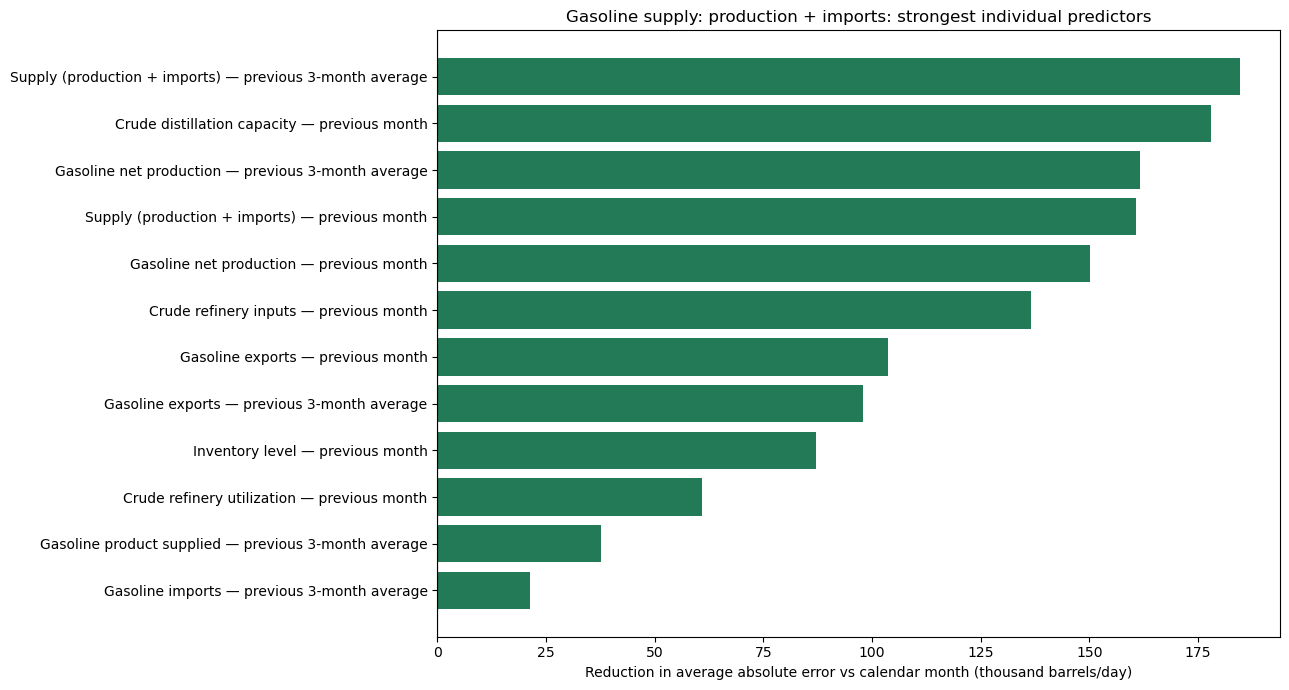

,Predictor,Error reduction vs calendar (thousand b/d),Error reduction vs calendar (%),Periods helped (of 6),Error increase when removed (thousand b/d),Periods hurt by removal (of 6)
Rank,,,,,,
1,Supply (production + imports) — previous 3-month average,184.63,53.35,5,0.68,5
2,Crude distillation capacity — previous month,178.07,51.46,5,4.47,3
3,Gasoline net production — previous 3-month average,161.67,46.71,5,0.45,4
4,Supply (production + imports) — previous month,160.77,46.46,4,0.44,4
5,Gasoline net production — previous month,150.09,43.37,5,0.79,5
6,Crude refinery inputs — previous month,136.48,39.44,5,-0.26,0
7,Gasoline exports — previous month,103.76,29.98,3,0.54,3
8,Gasoline exports — previous 3-month average,98.01,28.32,3,-0.03,3
9,Inventory level — previous month,87.24,25.21,3,0.20,3


### Demand: gasoline product supplied

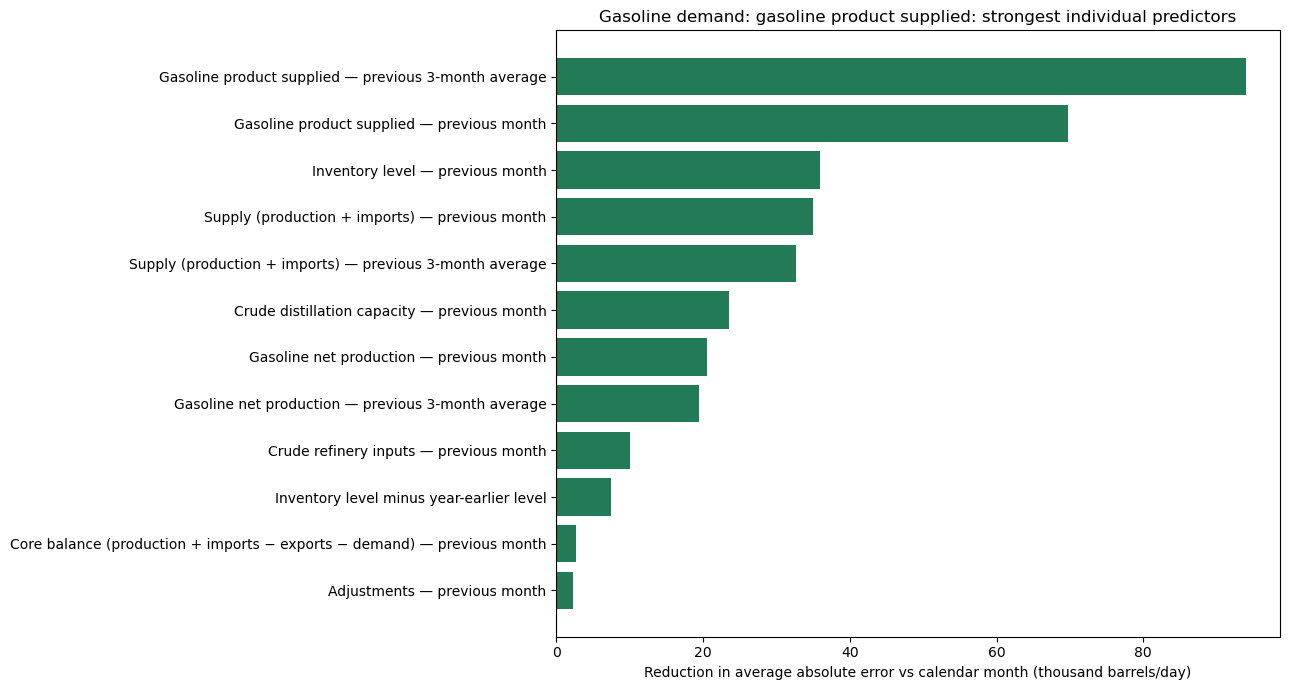

,Predictor,Error reduction vs calendar (thousand b/d),Error reduction vs calendar (%),Periods helped (of 6),Error increase when removed (thousand b/d),Periods hurt by removal (of 6)
Rank,,,,,,
1,Gasoline product supplied — previous 3-month average,93.92,46.40,6,9.18,6
2,Gasoline product supplied — previous month,69.71,34.44,5,0.80,5
3,Inventory level — previous month,36.00,17.78,3,-1.27,4
4,Supply (production + imports) — previous month,34.98,17.28,2,0.09,5
5,Supply (production + imports) — previous 3-month average,32.65,16.13,2,0.79,6
6,Crude distillation capacity — previous month,23.54,11.63,2,3.73,3
7,Gasoline net production — previous month,20.54,10.15,2,-0.00,4
8,Gasoline net production — previous 3-month average,19.48,9.63,2,0.77,5
9,Crude refinery inputs — previous month,10.04,4.96,2,0.22,3


In [5]:
for target_name, table in rankings.items():
    display(Markdown('### ' + target_name))
    top = table.head(12).iloc[::-1]
    fig, ax = plt.subplots(figsize=(13, 7))
    colors = ['#237a57' if value > 0 else '#b65a52' for value in top[gain_column]]
    ax.barh(top.Predictor, top[gain_column], color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(FUEL.title() + ' ' + target_name.lower() + ': strongest individual predictors')
    ax.set_xlabel('Reduction in average absolute error vs calendar month (thousand barrels/day)')
    ax.set_ylabel('')
    fig.tight_layout()
    plt.show()
    display(table.drop(columns=[f'Period {i} gain' for i in range(1, 7)]).round(2))


The three-month average of supply reduces error by about 185 thousand barrels/day versus calendar month alone.

For demand, the three-month average of product supplied reduces error by about 94 thousand barrels/day.

## Which variables matter alongside the others?

These rankings remove one input at a time from a ridge model. Positive values mean that removing the input makes predictions worse. Negative values mean predictions improve without it. 


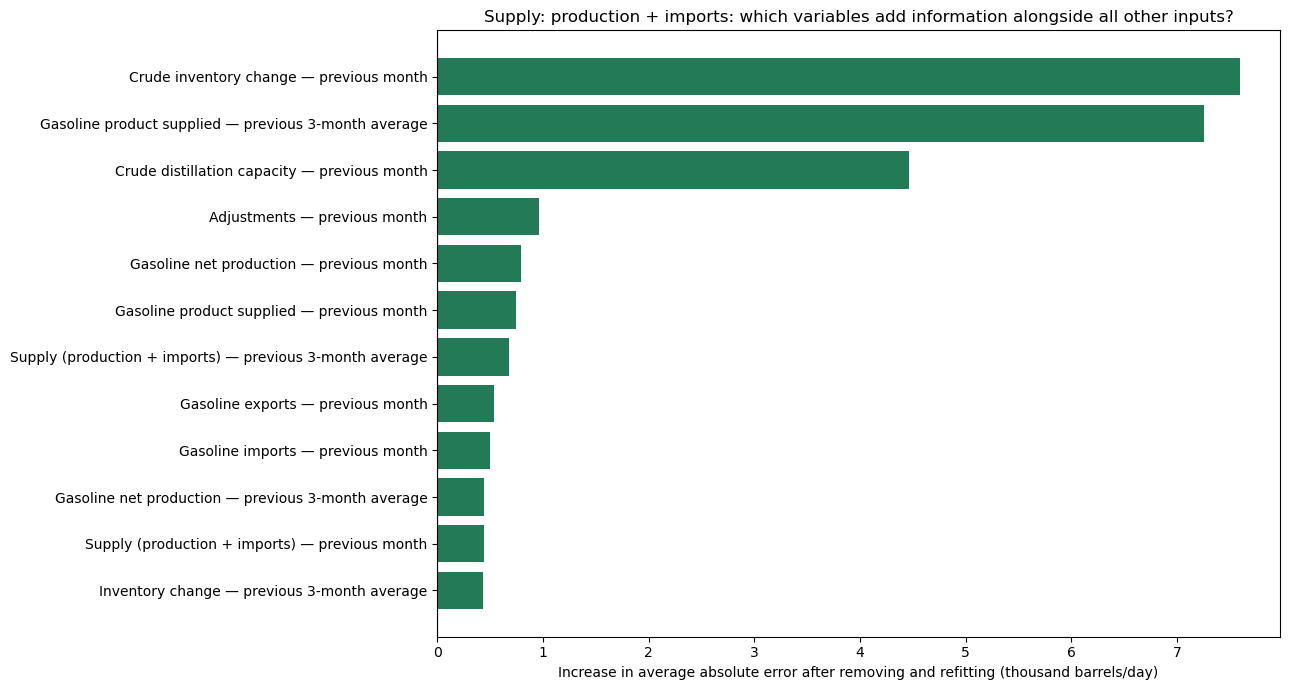

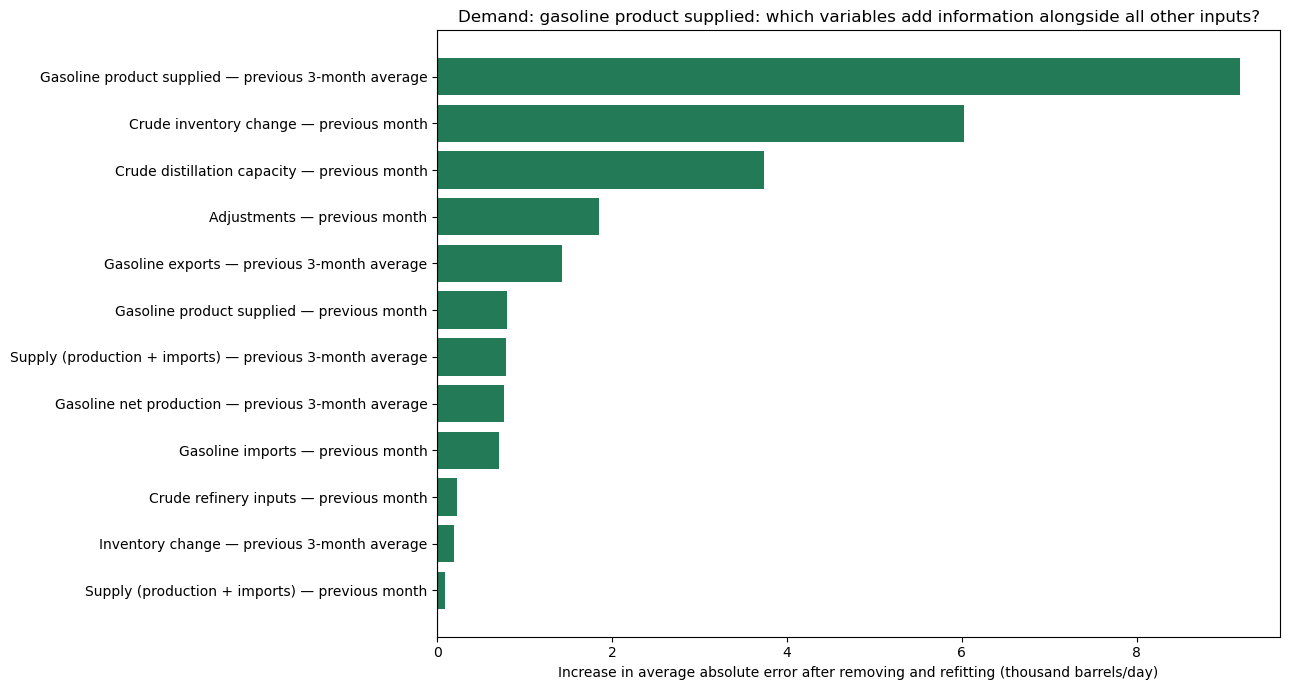

,Target,Predictor,Error increase when removed (thousand b/d)
0,Supply: production + imports,Calendar month (all 12 month indicators),47.96
1,Demand: gasoline product supplied,Calendar month (all 12 month indicators),39.84


In [6]:
for target_name, table in rankings.items():
    ordered = table.sort_values(conditional_column, ascending=False).head(12).iloc[::-1]
    fig, ax = plt.subplots(figsize=(13, 7))
    ax.barh(ordered.Predictor, ordered[conditional_column],
            color=['#237a57' if v > 0 else '#b65a52' for v in ordered[conditional_column]])
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(target_name + ': which variables add information alongside all other inputs?')
    ax.set_xlabel('Increase in average absolute error after removing and refitting (thousand barrels/day)')
    fig.tight_layout()
    plt.show()
display(pd.DataFrame(calendar_importance).round(2))


The previous month's crude inventory change adds the most information in the removal test for gasoline supply, as removing it increases error by about 7.6 thousand barrels/day.

For gasoline demand, the three-month average of product supplied adds the most information, as removing it increases error by about 9.2 thousand barrels/day.

Crude inventory change is weak on its own, as above it did not reduce error for either target, but it adds information alongside the other inputs. Removing it also increases demand error by about 6.0 thousand barrels/day.

## How consistent is each predictor?

In [7]:
for target_name, table in rankings.items():
    display(Markdown('### ' + target_name))
    columns = [f'Period {i} gain' for i in range(1, 7)]
    display(table.head(10).set_index('Predictor')[columns].round(2))
display(periods)


### Supply: production + imports

,Period 1 gain,Period 2 gain,Period 3 gain,Period 4 gain,Period 5 gain,Period 6 gain
Predictor,,,,,,
Supply (production + imports) — previous 3-month average,573.80,393.90,68.35,62.81,11.89,-2.96
Crude distillation capacity — previous month,528.58,373.17,41.02,109.87,-6.10,21.89
Gasoline net production — previous 3-month average,513.70,313.83,89.43,84.20,14.64,-45.81
Supply (production + imports) — previous month,543.46,375.31,11.24,46.20,-3.54,-8.03
Gasoline net production — previous month,484.04,321.54,47.90,68.14,24.41,-45.47
Crude refinery inputs — previous month,522.67,324.75,25.71,72.84,8.85,-135.96
Gasoline exports — previous month,489.40,325.83,-150.65,55.17,-18.86,-78.32
Gasoline exports — previous 3-month average,537.42,330.84,-184.64,40.68,-38.04,-98.22
Inventory level — previous month,426.06,224.20,-53.82,32.33,-18.61,-86.71


### Demand: gasoline product supplied

,Period 1 gain,Period 2 gain,Period 3 gain,Period 4 gain,Period 5 gain,Period 6 gain
Predictor,,,,,,
Gasoline product supplied — previous 3-month average,226.69,150.58,85.88,25.94,27.13,47.31
Gasoline product supplied — previous month,190.40,104.94,77.60,-6.00,13.83,37.52
Inventory level — previous month,215.47,92.19,38.08,-38.57,-28.44,-62.75
Supply (production + imports) — previous month,225.69,126.03,-35.80,-59.75,-20.37,-25.95
Supply (production + imports) — previous 3-month average,251.82,133.68,-43.69,-67.88,-39.45,-38.60
Crude distillation capacity — previous month,237.86,101.40,-10.18,-91.18,-81.24,-15.43
Gasoline net production — previous month,191.01,96.98,-43.01,-47.45,-31.98,-42.32
Gasoline net production — previous 3-month average,218.50,102.63,-51.28,-55.10,-45.04,-52.81
Crude refinery inputs — previous month,212.07,106.04,-36.26,-49.34,-69.32,-102.94


,Period,First scored month,Last scored month,Scored months,Earlier training months
0,1,2018-05,2019-04,12,123
1,2,2019-05,2022-06,12,135
2,3,2022-07,2023-06,12,147
3,4,2023-07,2024-06,12,159
4,5,2024-07,2025-06,12,171
5,6,2025-07,2026-06,12,183


The three-month average of supply, crude distillation capacity and the three-month average of gasoline net production help predict supply in five of six periods when tested individually.

For demand, the three-month average of product supplied helps in all six periods. The previous month's product supplied helps in five periods, while inventory level helps in three.

Crude inventory change helps individually in only two periods for each target, but removing it from the full model makes predictions worse in all six periods for both supply and demand.

## Conclusion

For gasoline supply, recent supply levels are the strongest individual predictors, with crude distillation capacity and gasoline net production as other strong predictors. For gasoline demand, recent product supplied is strongest. The three-month averages of supply and product supplied are stronger than their previous-month values.

Crude inventory change is weak on its own, but adds information alongside the other variables for both gasoline supply and demand. Gasoline inventory level is less consistent and does not improve the full demand model on average.

## Comparing crude and gasoline

Gasoline is easier to predict compared to crude based on these tests as its errors are smaller both in barrels/day and relative to the size of supply or demand.

The strongest predictors are similar, but the variables that add information alongside the other inputs differ.

Table below shows average absolute error by the average target level to account for crude volumes being larger than gasoline volumes.

| Target | Full-model error, thousand barrels/day | Error as % of average target | Best individual predictor + calendar: error % |
|---|---:|---:|---:|
| Crude supply | 354 | 1.82% | 1.81% |
| Gasoline supply | 138 | 1.40% | 1.63% |
| Crude demand | 338 | 2.07% | 1.57% |
| Gasoline demand | 110 | 1.22% | 1.20% |

Gasoline has lower relative errors for both targets, even when using just the strongest individual predictor plus calendar effects.

However, crude improves more relative to the baseline of only using the month of the year. Its full model reduces supply error by 89%, compared with 60% for gasoline. For demand, the reductions are 57% and 46%. This means crude has larger error reductions.

### Do the important predictors differ?

The strongest individual predictor are the same.

| Target | Crude | Gasoline |
|---|---|---|
| Supply | Previous three-month average of production + imports | Previous three-month average of production + imports |
| Demand | Previous three-month average of refinery inputs | Previous three-month average of product supplied |

Second most important predictors were:

- **Crude supply:** recent crude production 
- **Crude demand:** gasoline production

- **Gasoline supply:** crude distillation capacity
- **Gasoline demand:** recent product supplied


| Target | Largest error increase when a variable is removed |
|---|---|
| Crude supply | Crude year-over-year inventory difference: **17.1 thousand b/d** |
| Crude demand | Crude year-over-year inventory difference: **19.4 thousand b/d** |
| Gasoline supply | Previous-month crude inventory change: **7.6 thousand b/d** |
| Gasoline demand | Three-month average gasoline product supplied: **9.2 thousand b/d** |

Previous-month crude inventory change also helps the full gasoline demand model: removing it increases error by 6.0 thousand b/d.